# Recurrent Neural Network (RNN) for Sequence Classification

This notebook demonstrates the implementation and training of a simple Recurrent Neural Network (RNN) using PyTorch for a sequence classification task. It covers data loading, custom dataset and dataloader creation, model definition, training loop, and visualization of training progress.

### Notebook Structure:

1.  **Setup and Data Loading**: Imports necessary libraries and loads pre-processed data.
2.  **Dataset and DataLoader**: Defines a custom PyTorch Dataset and creates DataLoaders for training, validation, and testing.
3.  **Helper Functions**: Contains utility functions for setting random seeds, computing accuracy and confusion matrices, and plotting training results.
4.  **Model Definition**: Defines the RNN architecture using PyTorch's `nn.LSTM` and `nn.Linear` layers.
5.  **Model Training**: Sets up the model, optimizer, and executes the training loop.
6.  **Results Visualization**: Plots the training loss and accuracy over epochs.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset

## 1. Setup and Data Loading

This section handles the initial setup, including importing essential libraries and loading the pre-processed dataset from a `.npz` file.

In [ ]:
project_data = np.load("/content/project_data.npz", allow_pickle=True)

X_train_np = project_data['X_train']
y_train_np = project_data['y_train']
X_test_np = project_data['X_test']
y_test_np = project_data['y_test']

The `project_data.npz` file contains the training and testing features (`X`) and labels (`y`), which are loaded as NumPy arrays. These will later be converted to PyTorch tensors.

In [ ]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cpu


## 2. Dataset and DataLoader

This section defines a custom PyTorch `Dataset` to handle our data and creates `DataLoader` instances for efficient batching during training, validation, and testing.

Here we set up the `DEVICE` to utilize a GPU (CUDA) if available, otherwise, it defaults to the CPU. This ensures that computations are performed on the most efficient hardware.

In [ ]:
class My_Dataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    self.y = torch.tensor(y, dtype=torch.long).to(DEVICE)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

The `My_Dataset` class is a custom PyTorch `Dataset` that wraps our NumPy data. It converts the data to PyTorch tensors and moves them to the specified `DEVICE`. It also defines `__len__` to return the size of the dataset and `__getitem__` to retrieve individual samples.

In [ ]:
train_dataset = My_Dataset(X_train_np, y_train_np)
test_dataset = My_Dataset(X_test_np, y_test_np)

Instances of `My_Dataset` are created for both the training and testing sets, making them ready to be used with PyTorch's `DataLoader`.

We split the `train_dataset` into training and validation sets (90% training, 10% validation) and then create `DataLoader` instances. The `DataLoader`s handle batching, shuffling (for training), and loading data efficiently to the model.

In [ ]:
from torch.utils.data import DataLoader

validation = int(0.1 * len(train_dataset))
train_dataset, validation_dataset = torch.utils.data.random_split(train_dataset, [len(train_dataset) - validation, validation])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
valid_loader = DataLoader(validation_dataset, batch_size=8, shuffle=False)

Helper functions

In [ ]:
# imports from installed libraries
import os
import numpy as np
import random
import torch
from distutils.version import LooseVersion as Version
from itertools import product


def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def set_deterministic():
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

    if torch.__version__ <= Version("1.7"):
        torch.set_deterministic(True)
    else:
        torch.use_deterministic_algorithms(True)


def compute_accuracy(model, data_loader, device):

    with torch.no_grad():

        correct_pred, num_examples = 0, 0

        for i, (features, targets) in enumerate(data_loader):

            features = features.to(device)
            targets = targets.float().to(device)

            logits = model(features)
            _, predicted_labels = torch.max(logits, 1)

            num_examples += targets.size(0)
            correct_pred += (predicted_labels == targets).sum()
    return correct_pred.float()/num_examples * 100


def compute_confusion_matrix(model, data_loader, device):

    all_targets, all_predictions = [], []
    with torch.no_grad():

        for i, (features, targets) in enumerate(data_loader):

            features = features.to(device)
            targets = targets
            logits = model(features)
            _, predicted_labels = torch.max(logits, 1)
            all_targets.extend(targets.to('cpu'))
            all_predictions.extend(predicted_labels.to('cpu'))

    all_predictions = all_predictions
    all_predictions = np.array(all_predictions)
    all_targets = np.array(all_targets)

    class_labels = np.unique(np.concatenate((all_targets, all_predictions)))
    if class_labels.shape[0] == 1:
        if class_labels[0] != 0:
            class_labels = np.array([0, class_labels[0]])
        else:
            class_labels = np.array([class_labels[0], 1])
    n_labels = class_labels.shape[0]
    lst = []
    z = list(zip(all_targets, all_predictions))
    for combi in product(class_labels, repeat=2):
        lst.append(z.count(combi))
    mat = np.asarray(lst)[:, None].reshape(n_labels, n_labels)
    return mat

This block contains several helper functions:
*   `set_all_seeds`: Ensures reproducibility by setting random seeds across different libraries.
*   `set_deterministic`: Configures PyTorch for deterministic operations, further aiding reproducibility.
*   `compute_accuracy`: Calculates the accuracy of the model on a given dataset.
*   `compute_confusion_matrix`: Generates a confusion matrix to evaluate classification performance.

In [ ]:
import time
import torch

def train_model(model, num_epochs, train_loader,
                valid_loader, test_loader, optimizer,
                device, logging_interval=50,
                scheduler=None,
                scheduler_on='valid_acc'):

    start_time = time.time()
    minibatch_loss_list, train_acc_list, valid_acc_list = [], [], []

    for epoch in range(num_epochs):
        # print("Length for epoch: ",epoch," = ",len(train_loader))
        model.train()
        for batch_idx, (features, targets) in enumerate(train_loader):

            features = features.to(device)
            targets = targets.to(device)

            # ## FORWARD AND BACK PROP
            logits = model(features)
            loss = torch.nn.functional.cross_entropy(logits, targets)
            optimizer.zero_grad()

            loss.backward()

            # ## UPDATE MODEL PARAMETERS
            optimizer.step()

            # ## LOGGING
            minibatch_loss_list.append(loss.item())
            if not batch_idx % logging_interval:
                print(f'Epoch: {epoch+1:03d}/{num_epochs:03d} '
                      f'| Batch {batch_idx:04d}/{len(train_loader):04d} '
                      f'| Loss: {loss:.4f}')

        model.eval()
        with torch.no_grad():  # save memory during inference
            train_acc = compute_accuracy(model, train_loader, device=device)
            valid_acc = compute_accuracy(model, valid_loader, device=device)
            print(f'Epoch: {epoch+1:03d}/{num_epochs:03d} '
                  f'| Train: {train_acc :.2f}% '
                  f'| Validation: {valid_acc :.2f}%')
            train_acc_list.append(train_acc.item())
            valid_acc_list.append(valid_acc.item())

        elapsed = (time.time() - start_time)/60
        print(f'Time elapsed: {elapsed:.2f} min')

        if scheduler is not None:

            if scheduler_on == 'valid_acc':
                scheduler.step(valid_acc_list[-1])
            elif scheduler_on == 'minibatch_loss':
                scheduler.step(minibatch_loss_list[-1])
            else:
                raise ValueError(f'Invalid `scheduler_on` choice.')


    elapsed = (time.time() - start_time)/60
    print(f'Total Training Time: {elapsed:.2f} min')

    test_acc = compute_accuracy(model, test_loader, device=device)
    print(f'Test accuracy {test_acc :.2f}%')

    return minibatch_loss_list, train_acc_list, valid_acc_list


The `train_model` function encapsulates the core training loop. It iterates through epochs, processes data in minibatches, performs forward and backward passes, updates model parameters, and logs training and validation metrics. It also includes an optional learning rate scheduler.

In [ ]:
# imports from installed libraries
import os
import matplotlib.pyplot as plt
import numpy as np
import torch


def plot_training_loss(minibatch_loss_list, num_epochs, iter_per_epoch,
                       results_dir=None, averaging_iterations=100):

    plt.figure()
    ax1 = plt.subplot(1, 1, 1)
    ax1.plot(range(len(minibatch_loss_list)),
             (minibatch_loss_list), label='Minibatch Loss')

    if len(minibatch_loss_list) > 1000:
        ax1.set_ylim([
            0, np.max(minibatch_loss_list[1000:])*1.5
            ])
    ax1.set_xlabel('Iterations')
    ax1.set_ylabel('Loss')

    ax1.plot(np.convolve(minibatch_loss_list,
                         np.ones(averaging_iterations,)/averaging_iterations,
                         mode='valid'),
             label='Running Average')
    ax1.legend()

    ###################
    # Set scond x-axis
    ax2 = ax1.twiny()
    newlabel = list(range(num_epochs+1))

    newpos = [e*iter_per_epoch for e in newlabel]

    ax2.set_xticks(newpos[::10])
    ax2.set_xticklabels(newlabel[::10])

    ax2.xaxis.set_ticks_position('bottom')
    ax2.xaxis.set_label_position('bottom')
    ax2.spines['bottom'].set_position(('outward', 45))
    ax2.set_xlabel('Epochs')
    ax2.set_xlim(ax1.get_xlim())
    ###################

    plt.tight_layout()

    if results_dir is not None:
        image_path = os.path.join(results_dir, 'plot_training_loss.pdf')
        plt.savefig(image_path)


def plot_accuracy(train_acc_list, valid_acc_list, results_dir):

    num_epochs = len(train_acc_list)

    plt.plot(np.arange(1, num_epochs+1),
             train_acc_list, label='Training')
    plt.plot(np.arange(1, num_epochs+1),
             valid_acc_list, label='Validation')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()

    if results_dir is not None:
        image_path = os.path.join(
            results_dir, 'plot_acc_training_validation.pdf')
        plt.savefig(image_path)


def show_examples(model, data_loader, unnormalizer=None, class_dict=None):


    for batch_idx, (features, targets) in enumerate(data_loader):

        with torch.no_grad():
            features = features
            targets = targets
            logits = model(features)
            predictions = torch.argmax(logits, dim=1)
        break

    fig, axes = plt.subplots(nrows=3, ncols=5,
                             sharex=True, sharey=True)

    if unnormalizer is not None:
        for idx in range(features.shape[0]):
            features[idx] = unnormalizer(features[idx])
    nhwc_img = np.transpose(features, axes=(0, 2, 3, 1))

    if nhwc_img.shape[-1] == 1:
        nhw_img = np.squeeze(nhwc_img.numpy(), axis=3)

        for idx, ax in enumerate(axes.ravel()):
            ax.imshow(nhw_img[idx], cmap='binary')
            if class_dict is not None:
                ax.title.set_text(f'P: {class_dict[predictions[idx].item()]}'
                                  f'\nT: {class_dict[targets[idx].item()]}')
            else:
                ax.title.set_text(f'P: {predictions[idx]} | T: {targets[idx]}')
            ax.axison = False

    else:

        for idx, ax in enumerate(axes.ravel()):
            ax.imshow(nhwc_img[idx])
            if class_dict is not None:
                ax.title.set_text(f'P: {class_dict[predictions[idx].item()]}'
                                  f'\nT: {class_dict[targets[idx].item()]}')
            else:
                ax.title.set_text(f'P: {predictions[idx]} | T: {targets[idx]}')
            ax.axison = False
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(conf_mat,
                          hide_spines=False,
                          hide_ticks=False,
                          figsize=None,
                          cmap=None,
                          colorbar=False,
                          show_absolute=True,
                          show_normed=False,
                          class_names=None):

    if not (show_absolute or show_normed):
        raise AssertionError('Both show_absolute and show_normed are False')
    if class_names is not None and len(class_names) != len(conf_mat):
        raise AssertionError('len(class_names) should be equal to number of'
                             'classes in the dataset')

    total_samples = conf_mat.sum(axis=1)[:, np.newaxis]
    normed_conf_mat = conf_mat.astype('float') / total_samples

    fig, ax = plt.subplots(figsize=figsize)
    ax.grid(False)
    if cmap is None:
        cmap = plt.cm.Blues

    if figsize is None:
        figsize = (len(conf_mat)*1.25, len(conf_mat)*1.25)

    if show_normed:
        matshow = ax.matshow(normed_conf_mat, cmap=cmap)
    else:
        matshow = ax.matshow(conf_mat, cmap=cmap)

    if colorbar:
        fig.colorbar(matshow)

    for i in range(conf_mat.shape[0]):
        for j in range(conf_mat.shape[1]):
            cell_text = ""
            if show_absolute:
                cell_text += format(conf_mat[i, j], 'd')
                if show_normed:
                    cell_text += "\n" + '('
                    cell_text += format(normed_conf_mat[i, j], '.2f') + ')'
            else:
                cell_text += format(normed_conf_mat[i, j], '.2f')
            ax.text(x=j,
                    y=i,
                    s=cell_text,
                    va='center',
                    ha='center',
                    color="white" if normed_conf_mat[i, j] > 0.5 else "black")

    if class_names is not None:
        tick_marks = np.arange(len(class_names))
        plt.xticks(tick_marks, class_names, rotation=90)
        plt.yticks(tick_marks, class_names)

    if hide_spines:
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('bottom')
    if hide_ticks:
        ax.axes.get_yaxis().set_ticks([])
        ax.axes.get_xaxis().set_ticks([])

    plt.xlabel('predicted label')
    plt.ylabel('true label')
    return fig, ax

This section provides plotting utilities:
*   `plot_training_loss`: Visualizes the minibatch loss over iterations and epochs.
*   `plot_accuracy`: Displays the training and validation accuracy curves over epochs.
*   `show_examples`: Shows sample predictions from the model alongside their true labels.
*   `plot_confusion_matrix`: Renders a confusion matrix with absolute counts and/or normalized values.

Class Definition

In [ ]:
class RNN(torch.nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(RNN, self).__init__()
    self.hidden_size = hidden_size
    self.lstm = torch.nn.LSTM(input_size, hidden_size, batch_first=True)
    self.fc = torch.nn.Linear(hidden_size, output_size)

  def forward(self, x):
    x, h = self.lstm(x)
    x = self.fc(x[:, -1, :])
    return x

The `RNN` class defines our neural network architecture. It consists of an LSTM layer to process sequences and a fully connected layer to output the classification scores. The `forward` method specifies how input data flows through the layers.

In [ ]:
NUM_EPOCHS = 25

This cell defines the number of training epochs for the model.

In [ ]:
model = RNN(input_size=8, hidden_size=128, output_size=11).to(DEVICE)

model = model.to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

minibatch_loss_list, train_acc_list, valid_acc_list = train_model(
    model,
    num_epochs=NUM_EPOCHS,
    train_loader=train_loader,
    valid_loader=valid_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    device=DEVICE,
    scheduler=None,
    scheduler_on='valid_acc'
)

Epoch: 001/025 | Batch 0000/4557 | Loss: 2.4118
Epoch: 001/025 | Batch 0050/4557 | Loss: 2.0351
Epoch: 001/025 | Batch 0100/4557 | Loss: 2.1097
Epoch: 001/025 | Batch 0150/4557 | Loss: 1.8127
Epoch: 001/025 | Batch 0200/4557 | Loss: 1.8379
Epoch: 001/025 | Batch 0250/4557 | Loss: 1.8226
Epoch: 001/025 | Batch 0300/4557 | Loss: 1.7336
Epoch: 001/025 | Batch 0350/4557 | Loss: 2.2146
Epoch: 001/025 | Batch 0400/4557 | Loss: 1.7937
Epoch: 001/025 | Batch 0450/4557 | Loss: 1.9465
Epoch: 001/025 | Batch 0500/4557 | Loss: 1.3639
Epoch: 001/025 | Batch 0550/4557 | Loss: 1.2610
Epoch: 001/025 | Batch 0600/4557 | Loss: 1.1990
Epoch: 001/025 | Batch 0650/4557 | Loss: 1.5306
Epoch: 001/025 | Batch 0700/4557 | Loss: 1.7211
Epoch: 001/025 | Batch 0750/4557 | Loss: 1.7903
Epoch: 001/025 | Batch 0800/4557 | Loss: 2.2856
Epoch: 001/025 | Batch 0850/4557 | Loss: 2.2334
Epoch: 001/025 | Batch 0900/4557 | Loss: 1.6647
Epoch: 001/025 | Batch 0950/4557 | Loss: 1.5847
Epoch: 001/025 | Batch 1000/4557 | Loss:

The `RNN` model is instantiated with an input size of 8 (assuming 8 features per time step), a hidden size of 128, and an output size of 11 (for 11 classes). The Adam optimizer is used with a learning rate of 0.0001. The `train_model` function then orchestrates the entire training process.

## 4. Model Training and Evaluation

This section initializes the RNN model, sets up the optimizer, and initiates the training process using the `train_model` helper function. After training, it evaluates the model's performance on the test set.

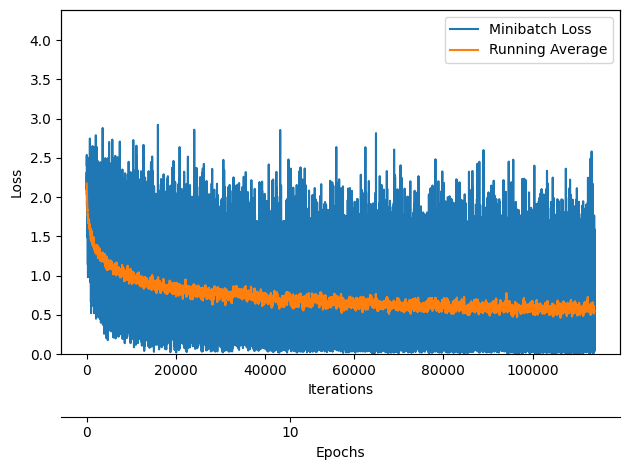

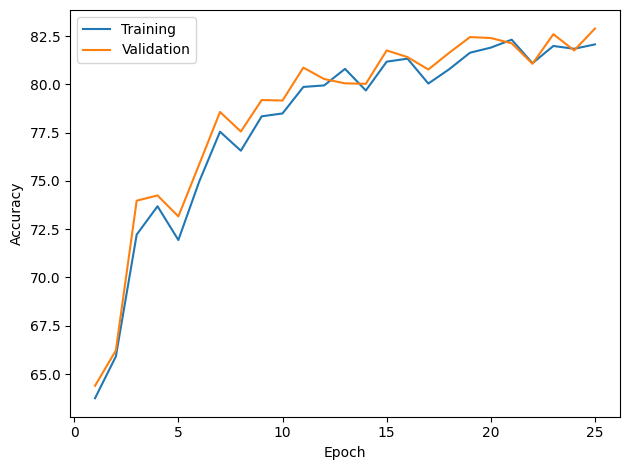

In [ ]:
plot_training_loss(minibatch_loss_list=minibatch_loss_list,
                   num_epochs=NUM_EPOCHS,
                   iter_per_epoch=len(train_loader),
                   results_dir=None,
                   averaging_iterations=100)
plt.show()

plot_accuracy(train_acc_list=train_acc_list,
              valid_acc_list=valid_acc_list,
              results_dir=None)
plt.show()

## 5. Results Visualization

This final section uses the plotting helper functions to visualize the training loss and accuracy curves, providing insights into the model's learning process and performance.